In [1]:
import os
import sys
import argparse
import time
import numpy as np
import pandas as pd
from typing import Optional, Set, List
from datetime import datetime
import pyarrow.parquet as pq
# Optional SciPy / Matplotlib imports
try:
    from scipy.stats import genextreme, kstest, probplot
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import matplotlib.pyplot as plt
    MPL_OK = True
except Exception:
    MPL_OK = False



In [2]:
METRICS      = ("producer_consumer", "consumer_application", "producer_application")
SCOPES       = ("global", "consumer_pod", "producer_pod")
SCOPE        = "global"
Home         = "/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/"
RUN_STAMP    = "20250905_124513/"             
PARQUET_ROOT = os.path.join(Home, RUN_STAMP, "consumer/", "consumer-sts-0_consumer-result/" ,"processed/2025-09-04/")
metrics_dir  = os.path.join(Home, RUN_STAMP,"merge", "merge-sts-0_merge-metrics")
block_path   = os.path.join(metrics_dir, "block_maxima.csv")
trim_levels  = [0.00, 0.01, 0.02, 0.05, 0.07, 0.10] 

In [3]:
PARQUET_ROOT

'/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/20250905_124513/consumer/consumer-sts-0_consumer-result/processed/2025-09-04/'

In [4]:
# -----------------------------
# Helpers
# -----------------------------
def list_parquet_files(root: str):
    out = []
    for r, _, fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(r, f))
    return sorted(out)


In [5]:
len(list_parquet_files(PARQUET_ROOT))

10364

In [6]:
def load_parquet_columns(parquet_path: str, needed_cols):
    needed = set(needed_cols)
    try:
        have = set(pq.read_schema(parquet_path).names)
        cols = list(needed & have)
        if not cols:
            return pd.DataFrame()
        return pd.read_parquet(parquet_path, columns=cols)
    except Exception:
        try:
            df = pd.read_parquet(parquet_path)
            keep = list(needed & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception as e2:
            print(f"[ERROR] Failed to read {os.path.basename(parquet_path)}: {e2}")
            return None

In [7]:
needed = { 
        "producer_timestamp", "consumer_receive_timestamp",
        "application_timestamp", "application_latency_seconds",
        "end_to_end_latency_seconds", "target_rate" , 
        "producer_pod", "consumer_pod",
    }

In [8]:
df = load_parquet_columns(PARQUET_ROOT , needed)

In [9]:
df["target_rate"].unique()[0]

250.0

In [10]:
# -----------------------------
# Load Parquet Files
# -----------------------------
def build_block_metadata_map(root_dir):
    """
    Returns a DataFrame indexed by block_id (filename sans .parquet)
    with at least the column 'target_rate' (mode per file).
    """
    files = list_parquet_files(root_dir)
    rows = []
    for p in files:
        try:
            df = pd.read_parquet(p, columns=["target_rate"])
        except Exception:
            # fallback: read all, then subset if present
            try:
                df = pd.read_parquet(p)
            except Exception:
                continue
        if "target_rate" not in df.columns or df["target_rate"].dropna().empty:
            continue
        tr = pd.to_numeric(df["target_rate"], errors="coerce").dropna()
        if tr.empty:
            continue
        block_id = os.path.splitext(os.path.basename(p))[0]
        rows.append({"block_id": block_id, "target_rate": float(tr.mode().iloc[0])})
    if not rows:
        return pd.DataFrame()
    md = pd.DataFrame(rows).drop_duplicates("block_id").set_index("block_id")
    return md
    


In [11]:
# -----------------------------
# Load block_maxima
# -----------------------------
if not os.path.exists(block_path):
    raise FileNotFoundError(f"block_maxima.csv not found at: {block_path}")

block_df = pd.read_csv(block_path)


In [12]:
# Add a block_id to parquet data frame
if "block_id" not in block_df.columns:
    if "file_name" not in block_df.columns:
        raise ValueError("block_maxima.csv missing both 'block_id' and 'file_name'.")
    block_df["block_id"] = (
        block_df["file_name"].astype(str).str.replace(r"\.parquet$", "", regex=True)
    )
    print("[INFO] Derived block_id from file_name.")
block_df["block_id"] = block_df["block_id"].astype(str)

[INFO] Derived block_id from file_name.


In [13]:
#print(block_df)
TARGET_RATE  = df["target_rate"].unique()[0]
TARGET_RATE

250.0

In [14]:
# Get per-block target_rate from THIS RUN's parquet tree
meta_df = build_block_metadata_map(PARQUET_ROOT)

if meta_df is None or meta_df.empty:
    print("⚠️  Could not build parquet metadata; proceeding without target_rate filter.")
else:
    # merge on block_id
    block_df = block_df.merge(meta_df, left_on="block_id", right_index=True, how="left")
    if "target_rate" in block_df.columns:
        block_df["target_rate"] = pd.to_numeric(block_df["target_rate"], errors="coerce")
    print("[INFO] After merge, target_rate value counts (top 8):")
    print(block_df["target_rate"].value_counts(dropna=False).head(8))
    
#print(meta_df)
#print(block_df)

[INFO] After merge, target_rate value counts (top 8):
target_rate
250.0    31092
Name: count, dtype: int64



Metric=producer_consumer | Scope=global | TARGET_RATE=250.0 | n=10364
GEV fit: c=-0.1448, loc=1.0368, scale=0.1134 | KS D=0.0339, p=0.0000


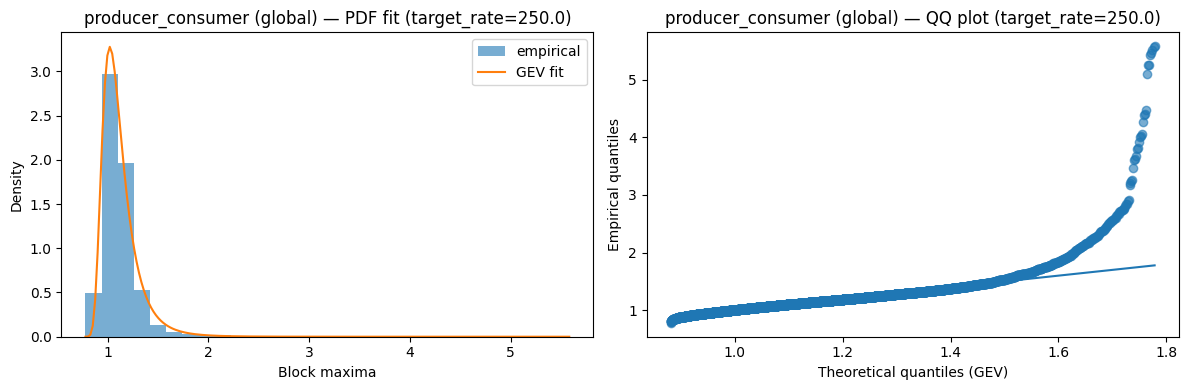

[INFO] Saved plot to /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/plots_tr250.0/pdfqq_producer_consumer_global_tr250.0.png

Metric=consumer_application | Scope=global | TARGET_RATE=250.0 | n=10364
GEV fit: c=1.0175, loc=0.0200, scale=0.0000 | KS D=0.0122, p=0.0923


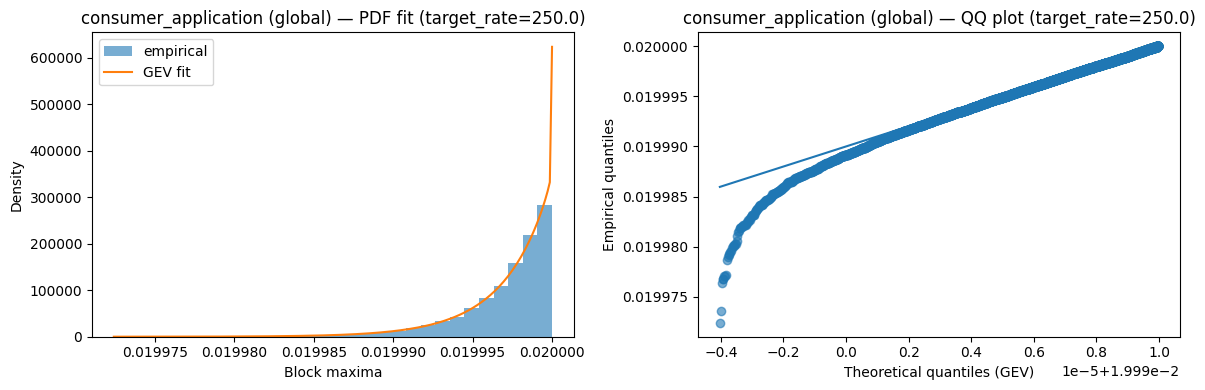

[INFO] Saved plot to /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/plots_tr250.0/pdfqq_consumer_application_global_tr250.0.png

Metric=producer_application | Scope=global | TARGET_RATE=250.0 | n=10364
GEV fit: c=-0.1453, loc=1.0495, scale=0.1133 | KS D=0.0338, p=0.0000


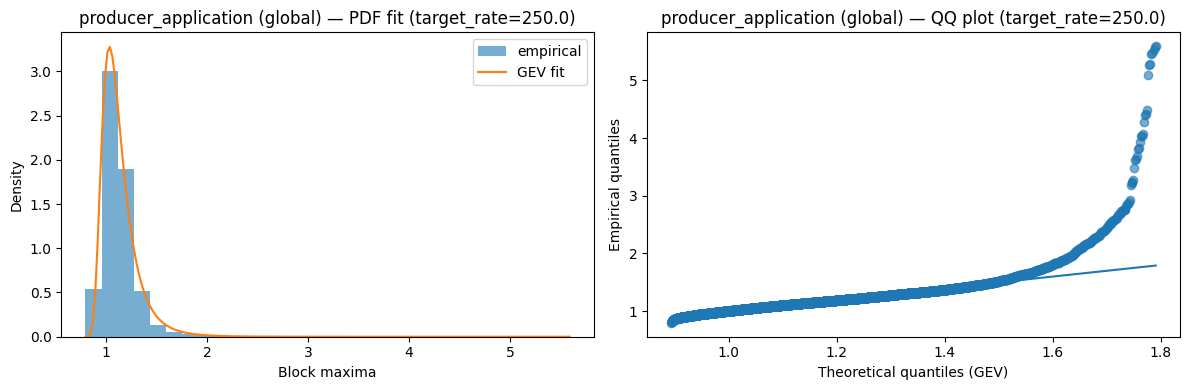

[INFO] Saved plot to /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/plots_tr250.0/pdfqq_producer_application_global_tr250.0.png


In [15]:
# -----------------------------
# Fit & Plot per metric
# -----------------------------

SCOPE    = "global"
metrics  = ["producer_consumer", "consumer_application", "producer_application"]
plot_dir = os.path.join(Home,"plots", f"plots_tr{TARGET_RATE}")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    mask = (block_df["metric"] == metric)
    nrows = int(mask.sum())
    if nrows == 0:
        print(f"⚠️  No rows for metric={metric} at scope={SCOPE}.")
        continue

    data = block_df.loc[mask, "block_max_value"].dropna().astype(float).values
    if len(data) < 5:
        print(f"⚠️  Not enough data for metric={metric} (n={len(data)}). Skipping.")
        continue

    # Fit GEV + KS
    c, loc, scale = genextreme.fit(data)
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))
    print(f"\nMetric={metric} | Scope={SCOPE} | TARGET_RATE={TARGET_RATE} | n={len(data)}")
    print(f"GEV fit: c={c:.4f}, loc={loc:.4f}, scale={scale:.4f} | KS D={D:.4f}, p={p:.4f}")

    # ---- Plot (one figure per metric) ----
    fig = plt.figure(figsize=(12, 4))
    
    # Left: histogram + fitted PDF
    ax1 = plt.subplot(1, 2, 1)
    x = np.linspace(float(np.min(data)), float(np.max(data)), 200)
    pdf = genextreme.pdf(x, c, loc=loc, scale=scale)
    ax1.hist(data, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(x, pdf, label="GEV fit")
    ax1.set_title(f"{metric} ({SCOPE}) — PDF fit (target_rate={TARGET_RATE})")
    ax1.set_xlabel("Block maxima")
    ax1.set_ylabel("Density")
    ax1.legend()

    # Right: QQ-plot
    ax2 = plt.subplot(1, 2, 2)
    emp_q = np.sort(data)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} ({SCOPE}) — QQ plot (target_rate={TARGET_RATE})")
    ax2.set_xlabel("Theoretical quantiles (GEV)")
    ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()

    out_path = os.path.join(plot_dir, f"pdfqq_{metric}_{SCOPE}_tr{TARGET_RATE}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[INFO] Saved plot to {out_path}")


In [16]:
def trim_top_pct(arr, pct):
    if pct <= 0:
        return arr
    cut = np.nanpercentile(arr, 100 * (1.0 - pct))
    return arr[arr <= cut]
    
def fit_and_ks(x):
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    return c, loc, scale, D, p


=== producer_consumer (scope=global, target_rate=250.0) ===
 trim=  0%: n=10364  KS D=0.0339  p=0.0000  (c=-0.1448, loc=1.0368, scale=0.1134)
 trim=  1%: n=10260  KS D=0.0180  p=0.0026  (c=-0.0415, loc=1.0391, scale=0.1098)
 trim=  2%: n=10156  KS D=0.0097  p=0.2939  (c=+0.0225, loc=1.0400, scale=0.1076)
 trim=  5%: n=9845  KS D=0.0135  p=0.0563  (c=+0.1444, loc=1.0400, scale=0.1028)
 trim=  7%: n=9638  KS D=0.0163  p=0.0118  (c=+0.1975, loc=1.0389, scale=0.1001)
 trim= 10%: n=9327  KS D=0.0189  p=0.0026  (c=+0.2608, loc=1.0367, scale=0.0965)


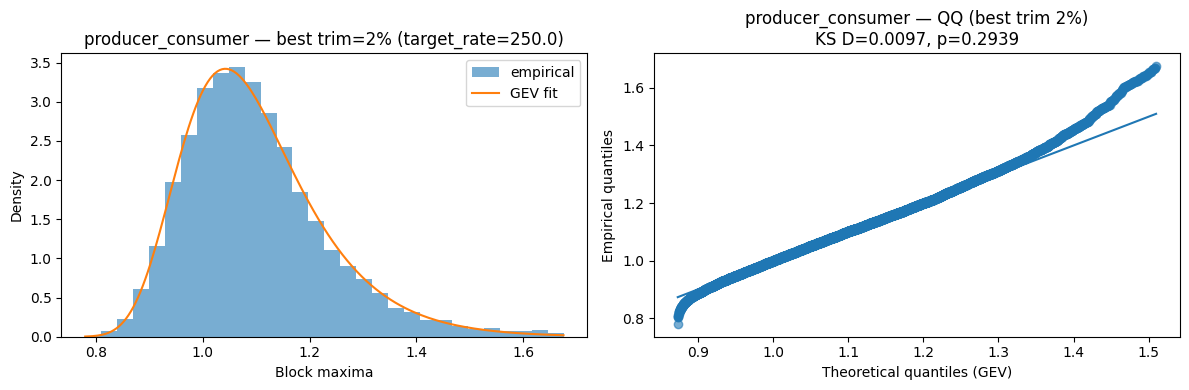

[PLOT] Saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/best_producer_consumer_trim2_tr250.0_global.png

=== consumer_application (scope=global, target_rate=250.0) ===
 trim=  0%: n=10364  KS D=0.0122  p=0.0923  (c=+1.0175, loc=0.0200, scale=0.0000)
 trim=  1%: n=10260  KS D=0.0118  p=0.1156  (c=+1.0204, loc=0.0200, scale=0.0000)
 trim=  2%: n=10156  KS D=0.0071  p=0.6747  (c=+1.0018, loc=0.0200, scale=0.0000)
 trim=  5%: n=9845  KS D=0.0149  p=0.0254  (c=+1.0107, loc=0.0200, scale=0.0000)
 trim=  7%: n=9638  KS D=0.0086  p=0.4643  (c=+1.0031, loc=0.0200, scale=0.0000)
 trim= 10%: n=9327  KS D=0.0087  p=0.4714  (c=+0.9949, loc=0.0200, scale=0.0000)


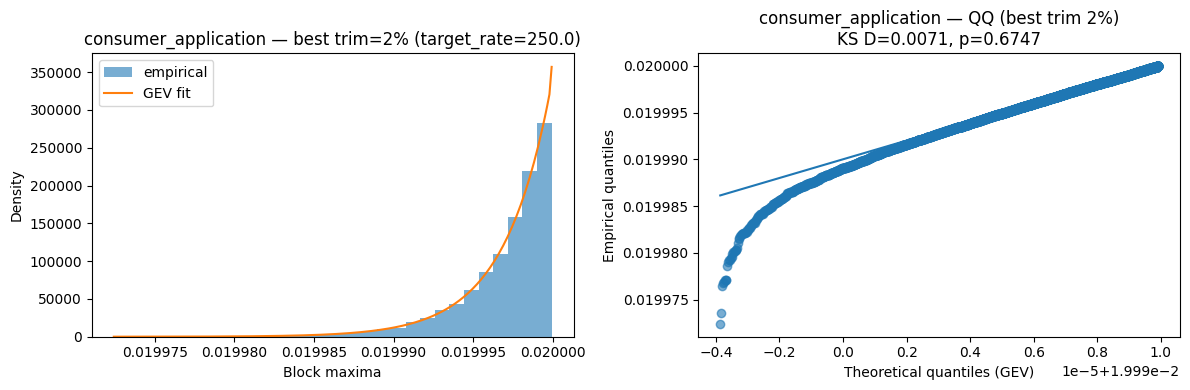

[PLOT] Saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/best_consumer_application_trim2_tr250.0_global.png

=== producer_application (scope=global, target_rate=250.0) ===
 trim=  0%: n=10364  KS D=0.0338  p=0.0000  (c=-0.1453, loc=1.0495, scale=0.1133)
 trim=  1%: n=10260  KS D=0.0179  p=0.0028  (c=-0.0422, loc=1.0518, scale=0.1097)
 trim=  2%: n=10156  KS D=0.0096  p=0.3030  (c=+0.0218, loc=1.0526, scale=0.1074)
 trim=  5%: n=9845  KS D=0.0138  p=0.0456  (c=+0.1438, loc=1.0526, scale=0.1027)
 trim=  7%: n=9638  KS D=0.0157  p=0.0168  (c=+0.1972, loc=1.0516, scale=0.1000)
 trim= 10%: n=9327  KS D=0.0191  p=0.0021  (c=+0.2598, loc=1.0493, scale=0.0964)


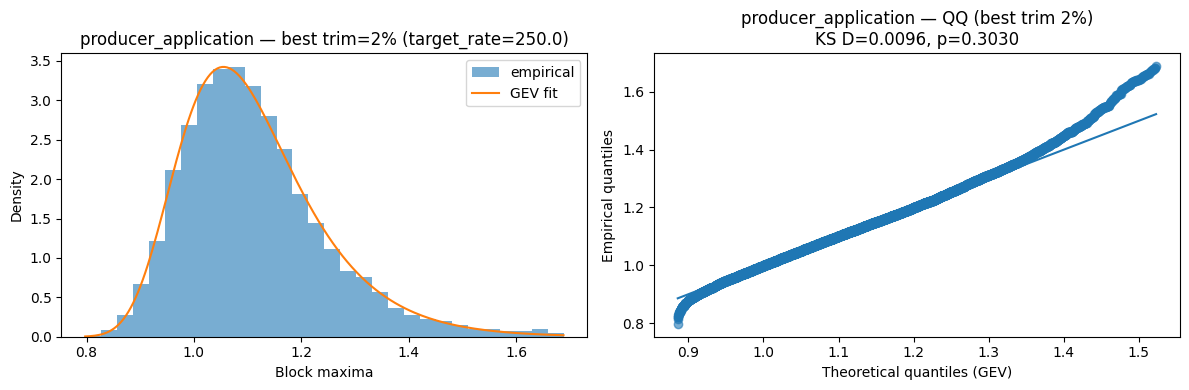

[PLOT] Saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/best_producer_application_trim2_tr250.0_global.png

=== Best trim per metric (by KS p-value) ===
producer_consumer       trim= 2%  n=10156  KS D=0.0097  p=0.2939  c=+0.0225  loc=1.0400  scale=0.1076
consumer_application    trim= 2%  n=10156  KS D=0.0071  p=0.6747  c=+1.0018  loc=0.0200  scale=0.0000
producer_application    trim= 2%  n=10156  KS D=0.0096  p=0.3030  c=+0.0218  loc=1.0526  scale=0.1074


In [17]:
# ---------- Trim search & plotting ----------

results  = []
plot_dir = os.path.join(Home, "plots")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    raw = block_df.loc[block_df["metric"] == metric, "block_max_value"].dropna().astype(float).values
    if raw.size < 10:
        print(f"⚠️ Not enough data for {metric} (n={raw.size}). Skipping.")
        continue

    best = None  # (p, D, c, loc, scale, pct, n)
    print(f"\n=== {metric} (scope={SCOPE}, target_rate={TARGET_RATE}) ===")
    for pct in trim_levels:
        x = trim_top_pct(raw, pct)
        if x.size < 10:
            print(f" trim={pct:>4.0%}: n={x.size:4d}  -> skip (too few)")
            continue
        c, loc, scale, D, p = fit_and_ks(x)
        print(f" trim={pct:>4.0%}: n={x.size:4d}  KS D={D:0.4f}  p={p:0.4f}  (c={c:+.4f}, loc={loc:.4f}, scale={scale:.4f})")
        if (best is None) or (p > best[0]):
            best = (p, D, c, loc, scale, pct, x.size)

    if best is None:
        continue
    p, D, c, loc, scale, pct, n = best
    results.append({
        "metric": metric, "best_trim": pct, "n": n,
        "KS_D": D, "KS_p": p, "c": c, "loc": loc, "scale": scale
    })

    # plot ONLY best trim
    xdat = trim_top_pct(raw, pct)
    fig = plt.figure(figsize=(12,4))

    # PDF overlay
    ax1 = plt.subplot(1,2,1)
    xx = np.linspace(float(np.min(xdat)), float(np.max(xdat)), 200)
    pdf = genextreme.pdf(xx, c, loc=loc, scale=scale)
    ax1.hist(xdat, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(xx, pdf, label="GEV fit")
    ax1.set_title(f"{metric} — best trim={int(pct*100)}% (target_rate={TARGET_RATE})")
    ax1.set_xlabel("Block maxima"); ax1.set_ylabel("Density"); ax1.legend()
    # QQ
    ax2 = plt.subplot(1,2,2)
    emp_q  = np.sort(xdat)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} — QQ (best trim {int(pct*100)}%)\nKS D={D:.4f}, p={p:.4f}")
    ax2.set_xlabel("Theoretical quantiles (GEV)"); ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"best_{metric}_trim{int(pct*100)}_tr{TARGET_RATE}_{SCOPE}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[PLOT] Saved {out_path}")
    
# quick summary
if results:
    print("\n=== Best trim per metric (by KS p-value) ===")
    for r in results:
        print(f"{r['metric']:22s}  trim={int(r['best_trim']*100):2d}%  n={r['n']:4d}  "
              f"KS D={r['KS_D']:.4f}  p={r['KS_p']:.4f}  "
              f"c={r['c']:+.4f}  loc={r['loc']:.4f}  scale={r['scale']:.4f}")
else:
    print("No results to summarize.")

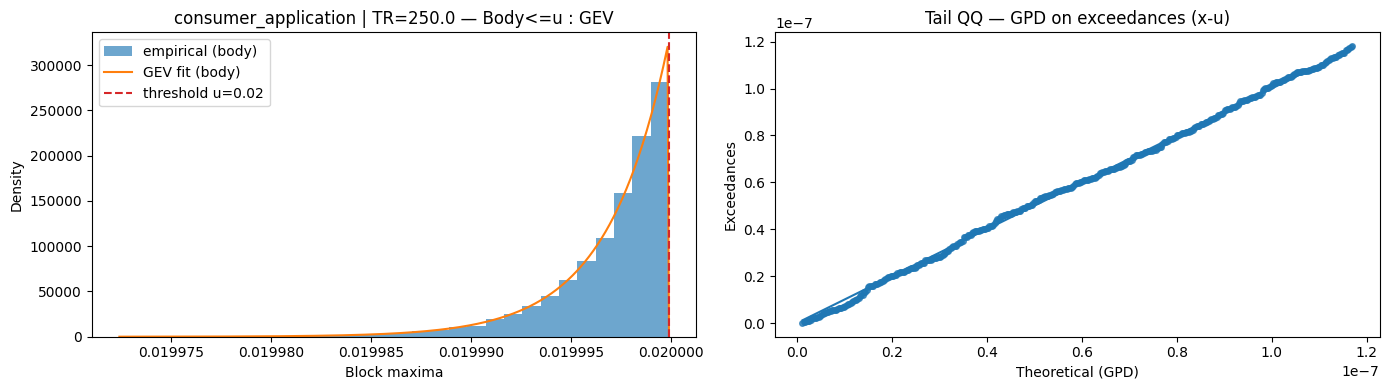

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/spliced_evt/spliced_gev_gpd_consumer_application_tr250.0.png


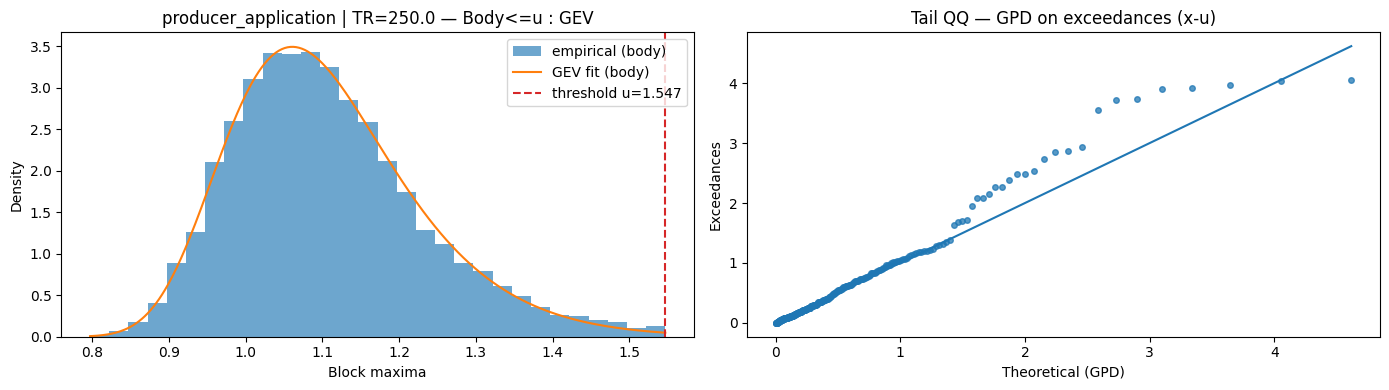

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/spliced_evt/spliced_gev_gpd_producer_application_tr250.0.png


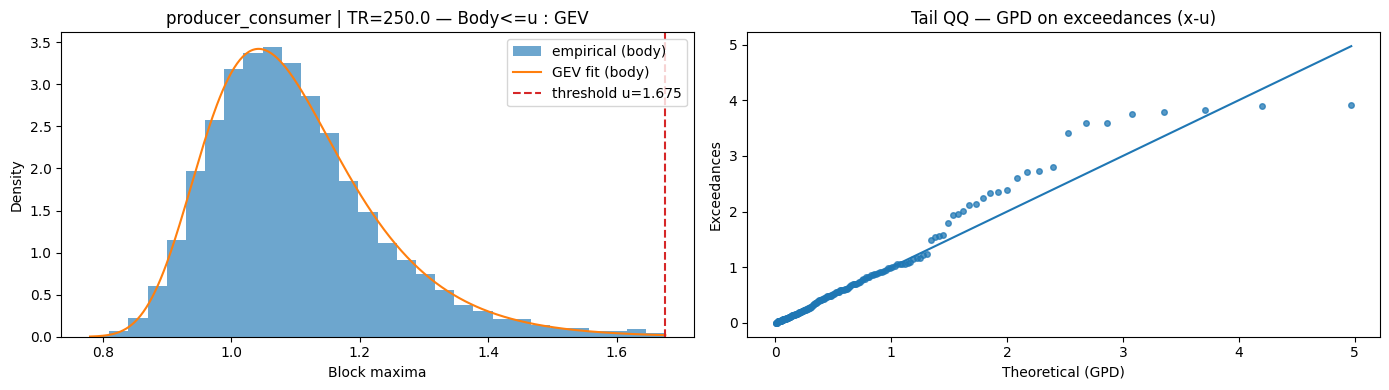

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/spliced_evt/spliced_gev_gpd_producer_consumer_tr250.0.png
[SAVE] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/spliced_evt/evt_fit_summary.csv


,metric,target_rate,n_total,u,q_u,n_body,n_tail,gev_c,gev_loc,gev_scale,gev_KS_D,gev_KS_p,gpd_xi,gpd_beta,gpd_KS_D,gpd_KS_p,best_trim_pct,pot_best_q,pot_gpd_p
0,consumer_application,250.0,10364,0.020000,0.959958,9949,415,1.000246,0.019997,0.000003,0.014341,0.033075,-1.007223,1.189267e-07,0.025868,0.937192,0.02,0.96,0.937192
1,producer_application,250.0,10364,1.546683,0.969992,10053,311,0.071470,1.053023,0.105678,0.008020,0.534792,0.394541,3.533903e-01,0.029116,0.947691,0.02,0.97,0.947691
2,producer_consumer,250.0,10364,1.675381,0.979931,10156,208,0.022519,1.039977,0.107558,0.009692,0.293933,0.333728,4.545662e-01,0.035257,0.950133,0.02,0.98,0.950133


In [18]:
import os, numpy as np, pandas as pd
from scipy.stats import genextreme, genpareto, kstest
import matplotlib.pyplot as plt

# ---------- utilities ----------
def ks_gpd(exceedances):
    """KS test for GPD on exceedances (loc=0). Returns (xi, beta, D, p, n)."""
    if len(exceedances) < 10:
        return np.nan, np.nan, np.nan, np.nan, len(exceedances)
    # fit with loc fixed at 0 because we already subtract u
    xi, loc, beta = genpareto.fit(exceedances, floc=0.0)
    D, p = kstest(exceedances, 'genpareto', args=(xi, 0.0, beta))
    return xi, beta, D, p, len(exceedances)

def ks_gev(x):
    """KS test for GEV on data x."""
    if len(x) < 10:
        return np.nan, np.nan, np.nan, np.nan, len(x)
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    return c, loc, scale, D, p, len(x)

def choose_threshold(x, min_exc=30, q_grid=None):
    """
    POT threshold selection by short grid search.
    Returns dict with best threshold by KS p-value on GPD.
    """
    x = np.asarray(x, float)
    if q_grid is None:
        # Try from 90th to 99.5th percentile
        q_grid = np.concatenate([
            np.linspace(0.90, 0.98, 9),
            np.linspace(0.985, 0.995, 5)
        ])
    best = None
    rows = []
    for q in q_grid:
        u = np.quantile(x, q)
        exc = x[x > u] - u
        if exc.size < min_exc:
            continue
        xi, beta, D, p, n = ks_gpd(exc)
        rows.append((q, u, n, xi, beta, D, p))
        if (best is None) or (p > best["gpd_ks_p"]):
            best = {"q": q, "u": u, "n_exc": n, "xi": xi, "beta": beta, "gpd_ks_D": D, "gpd_ks_p": p}
    return best, pd.DataFrame(rows, columns=["q","u","n_exc","xi","beta","KS_D","KS_p"])

def splice_cdf_params(body_params, tail_params, u, F_u):
    """
    Pack parameters for a spliced body+tail CDF if you need to evaluate it later.
    body_params=(c,loc,scale) for GEV on x<=u
    tail_params=(xi,beta) for GPD on (x-u) | x>u
    F_u is empirical body CDF at u.
    """
    return {"u":u, "F_u":F_u, "gev":body_params, "gpd":tail_params}

def plot_body_tail(x, metric, tr, u, gev_pars, gpd_pars, outdir):
    os.makedirs(outdir, exist_ok=True)
    x = np.asarray(x, float)
    body = x[x <= u]
    tail = x[x > u]

    # ---- Left: body histogram + GEV pdf overlay ----
    fig = plt.figure(figsize=(14,4))
    ax1 = plt.subplot(1,2,1)
    bins = 30 if body.size>=30 else max(10, body.size//2)
    ax1.hist(body, bins=bins, density=True, alpha=0.65, label="empirical (body)")
    c, loc, scale = gev_pars
    grid = np.linspace(body.min(), max(body.max(), u), 400)
    ax1.plot(grid, genextreme.pdf(grid, c, loc=loc, scale=scale), label="GEV fit (body)")
    ax1.axvline(u, color="tab:red", ls="--", lw=1.5, label=f"threshold u={u:,.4g}")
    ax1.set_title(f"{metric} | TR={tr} — Body<=u : GEV")
    ax1.set_xlabel("Block maxima"); ax1.set_ylabel("Density"); ax1.legend()

    # ---- Right: tail QQ for GPD ----
    ax2 = plt.subplot(1,2,2)
    if tail.size > 0:
        exc = tail - u
        xi, beta = gpd_pars
        emp = np.sort(exc)
        theo = genpareto.ppf(np.linspace(0.01, 0.99, len(emp)), xi, loc=0, scale=beta)
        ax2.scatter(theo, emp, s=16, alpha=0.75)
        lo, hi = np.nanmin(theo), np.nanmax(theo)
        ax2.plot([lo, hi], [lo, hi], lw=1.5)
        ax2.set_title("Tail QQ — GPD on exceedances (x-u)")
        ax2.set_xlabel("Theoretical (GPD)"); ax2.set_ylabel("Exceedances")
    else:
        ax2.text(0.5,0.5,"No exceedances over u", ha="center", va="center", transform=ax2.transAxes)
        ax2.set_axis_off()

    plt.tight_layout()
    fname = os.path.join(outdir, f"spliced_gev_gpd_{metric}_tr{tr}.png")
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"[PLOT] {fname}")

# ---------- main driver ----------
def fit_spliced_evt(block_df, outdir, min_exc=30, trim_levels=(0.0,0.01,0.02,0.05,0.07,0.10)):
    """
    For each (metric, target_rate):
      - propose u from 'best trim' (if any) and from POT sweep
      - fit GEV to body x<=u
      - fit GPD to exceedances x>u
      - save plot + summary row
    """
    assert {"metric","block_max_value","target_rate"}.issubset(block_df.columns)
    rows = []
    for (metric, tr), g in block_df.groupby(["metric","target_rate"]):
        x = g["block_max_value"].dropna().astype(float).values
        if x.size < 50:
            print(f"Skip {metric} TR={tr}: not enough data (n={x.size})")
            continue

        # 1) candidate threshold from your "best trim" search (use highest p-value trim as proxy)
        #    Here we reuse your trim grid to propose 'q_from_trim'
        q_from_trim = None
        best_trim = None
        # emulate your trim search quickly to find best p (as you did previously)
        best_p = -np.inf
        for pct in trim_levels:
            cut = np.nanpercentile(x, 100*(1-pct))
            body_tmp = x[x <= cut]
            if body_tmp.size < 30:
                continue
            c, loc, scale, D, p, _ = ks_gev(body_tmp)
            if np.isfinite(p) and p > best_p:
                best_p = p
                best_trim = pct
                q_from_trim = 1.0 - pct

        # 2) full POT sweep to choose u by GPD KS p-value
        best_gpd, grid_tbl = choose_threshold(x, min_exc=min_exc)

        # 3) pick the better source of u (prefer POT p-value; fall back to trim proxy)
        if best_gpd is not None:
            u = best_gpd["u"]
        elif q_from_trim is not None:
            u = np.quantile(x, q_from_trim)
        else:
            # conservative: 95th percentile
            u = np.quantile(x, 0.95)

        tail = x[x > u]; body = x[x <= u]
        if tail.size < min_exc:
            # raise u/lower exc requirement if tail too small
            print(f"{metric} TR={tr}: tail too small over u; raising to 97.5th pct.")
            u = np.quantile(x, 0.975)
            tail = x[x > u]; body = x[x <= u]

        # 4) fit GEV on body; fit GPD on exceedances (x>u)
        c, loc, scale, D_body, p_body, n_body = ks_gev(body)
        xi, beta, D_tail, p_tail, n_tail = ks_gpd(tail - u)

        # 5) plots
        plot_body_tail(x, metric, tr, u, (c,loc,scale), (xi,beta), outdir)

        # 6) save summary row
        rows.append({
            "metric": metric, "target_rate": tr, "n_total": x.size,
            "u": u, "q_u": (x <= u).mean(), "n_body": n_body, "n_tail": n_tail,
            "gev_c": c, "gev_loc": loc, "gev_scale": scale, "gev_KS_D": D_body, "gev_KS_p": p_body,
            "gpd_xi": xi, "gpd_beta": beta, "gpd_KS_D": D_tail, "gpd_KS_p": p_tail,
            "best_trim_pct": best_trim, 
            "pot_best_q": (None if best_gpd is None else best_gpd["q"]),
            "pot_gpd_p": (None if best_gpd is None else best_gpd["gpd_ks_p"])
        })

    summ = pd.DataFrame(rows).sort_values(["metric","target_rate"]).reset_index(drop=True)
    os.makedirs(outdir, exist_ok=True)
    csv_path = os.path.join(outdir, "evt_fit_summary.csv")
    summ.to_csv(csv_path, index=False)
    print(f"[SAVE] {csv_path}")
    display(summ.head(10))
    return summ

# ---------- run it ----------
# Use your existing 'block_df' as constructed earlier (merged with target_rate).
spliced_outdir = os.path.join(Home, "plots", "spliced_evt")
summary = fit_spliced_evt(block_df, spliced_outdir, min_exc=30)


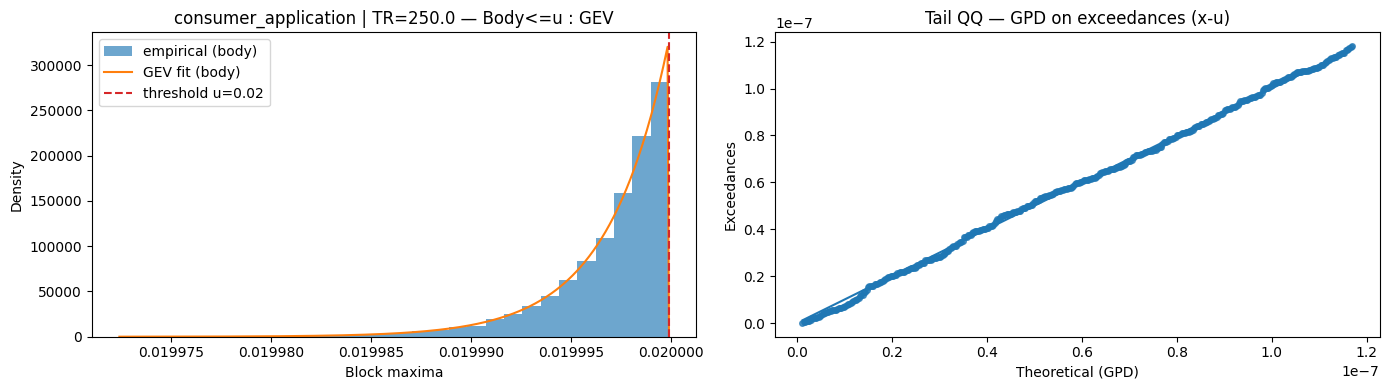

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/evt_trim_results/tr_250.0/spliced_gev_gpd_consumer_application_tr250.0.png


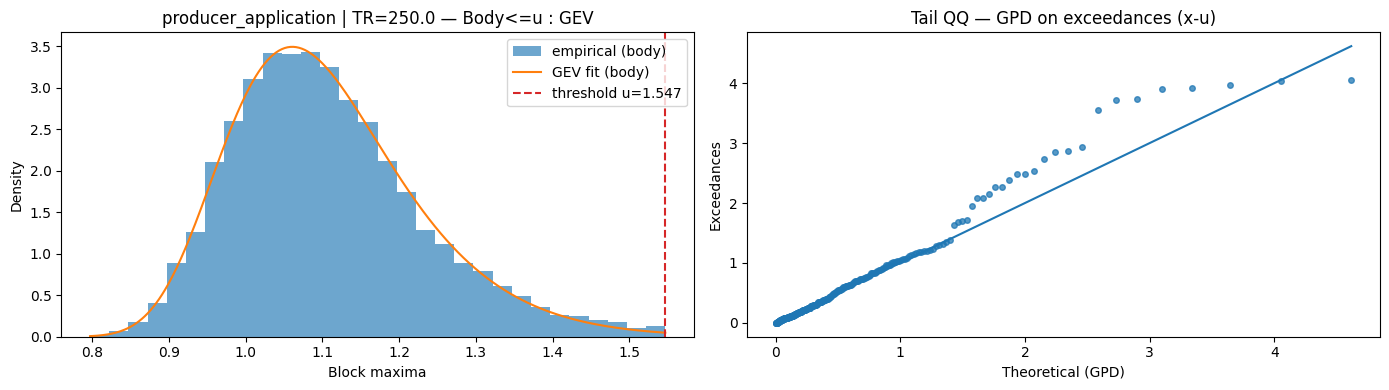

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/evt_trim_results/tr_250.0/spliced_gev_gpd_producer_application_tr250.0.png


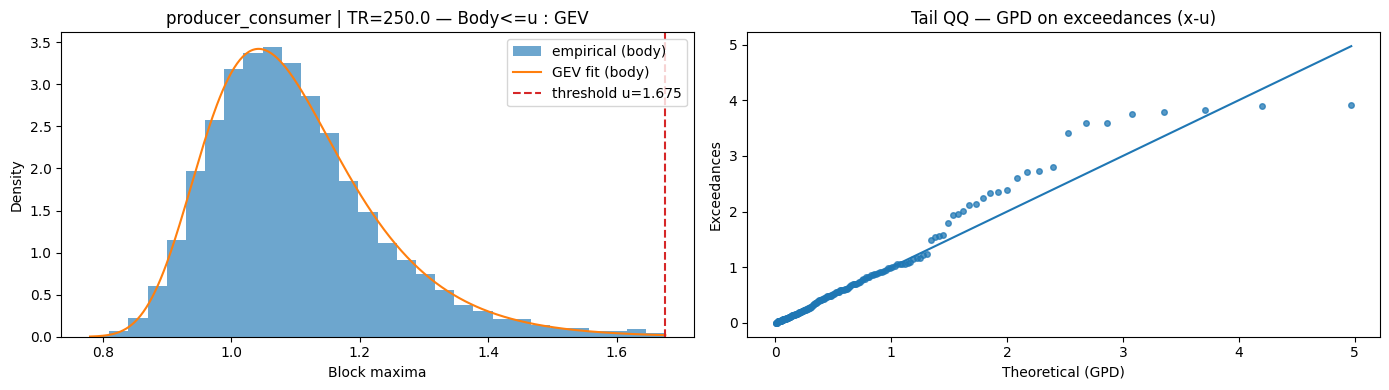

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/evt_trim_results/tr_250.0/spliced_gev_gpd_producer_consumer_tr250.0.png
[SAVE] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/evt_trim_results/tr_250.0/evt_fit_summary.csv


,metric,target_rate,n_total,u,q_u,n_body,n_tail,gev_c,gev_loc,gev_scale,gev_KS_D,gev_KS_p,gpd_xi,gpd_beta,gpd_KS_D,gpd_KS_p,best_trim_pct,pot_best_q,pot_gpd_p
0,consumer_application,250.0,10364,0.020000,0.959958,9949,415,1.000246,0.019997,0.000003,0.014341,0.033075,-1.007223,1.189267e-07,0.025868,0.937192,0.02,0.96,0.937192
1,producer_application,250.0,10364,1.546683,0.969992,10053,311,0.071470,1.053023,0.105678,0.008020,0.534792,0.394541,3.533903e-01,0.029116,0.947691,0.02,0.97,0.947691
2,producer_consumer,250.0,10364,1.675381,0.979931,10156,208,0.022519,1.039977,0.107558,0.009692,0.293933,0.333728,4.545662e-01,0.035257,0.950133,0.02,0.98,0.950133


Saved plots & summary to:
/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/evt_trim_results/tr_250.0


In [19]:

bdf= block_df[np.isclose(block_df["target_rate"].astype(float), TARGET_RATE )]

outdir = os.path.join( 
    "/Users/soheila/Desktop/RealTime-Streaming-Pipeline/",
    "results",                
    "plots",
    "evt_trim_results",
    "tr_"+str(TARGET_RATE)
)

summary = fit_spliced_evt(bdf, outdir, min_exc=30)

print(f"Saved plots & summary to:\n{outdir}")

In [20]:
# === EVT add-ons: threshold selection, GPD QQ with envelope, stability diagnostics ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, kstest, genextreme

# ------- helpers (tail/exceedances) -------
def _exceedances(x, u, jitter=None, clip_min=1e-15):
    y = np.asarray(x, float)
    e = y[y > u] - u
    if jitter and jitter > 0:
        e = e + np.random.uniform(-jitter, jitter, size=e.size)
    if clip_min is not None:
        e = np.clip(e, clip_min, None)
    return e

def _fit_gpd_loc0(exceed):
    """Fit GPD to exceedances with loc fixed at 0."""
    if exceed.size < 10:
        return np.nan, np.nan
    xi, loc, beta = genpareto.fit(exceed, floc=0.0)
    return float(xi), float(beta)

def _ks_gpd_loc0(exceed):
    """KS test for GPD with loc=0 on exceedances."""
    if exceed.size < 10:
        return np.nan, np.nan
    xi, beta = _fit_gpd_loc0(exceed)
    D, p = kstest(exceed, 'genpareto', args=(xi, 0.0, beta))
    return float(D), float(p)

# ------- threshold sweep with stability preference -------
def sweep_threshold_with_stability(x, 
                                  q_grid=None, 
                                  min_exc=30, 
                                  jitter=None,
                                  rolling_k=5,
                                  prefer_stability=True):
    """
    Try a grid of quantiles for u; compute (xi, beta, KS D, KS p, n_exc) for exceedances.
    Optionally prefer thresholds where (xi, beta) are locally stable (low rolling std).
    Returns (best_row_as_dict, full_table).
    """
    x = np.asarray(x, float)
    if q_grid is None:
        q_grid = np.r_[np.linspace(0.95, 0.985, 8),
                       np.linspace(0.99, 0.995, 6)]
    rows = []
    for q in q_grid:
        u = np.quantile(x, q)
        exc = _exceedances(x, u, jitter=jitter)
        n_exc = exc.size
        if n_exc < min_exc:
            continue
        xi, beta = _fit_gpd_loc0(exc)
        D, p = _ks_gpd_loc0(exc)
        rows.append((q, u, n_exc, xi, beta, D, p))
    tbl = pd.DataFrame(rows, columns=["q", "u", "n_exc", "xi", "beta", "KS_D", "KS_p"])
    if tbl.empty:
        return None, tbl

    # local stability via rolling std
    if prefer_stability and len(tbl) >= rolling_k:
        xi_sd   = tbl["xi"].rolling(rolling_k, center=True).std()
        beta_sd = tbl["beta"].rolling(rolling_k, center=True).std()
        # Use medians to set soft thresholds
        xi_cut   = 0.15 * np.nanmedian(np.abs(tbl["xi"])) + 0.02
        beta_cut = 0.15 * np.nanmedian(tbl["beta"]) + 0.02 * np.nanmedian(tbl["beta"])
        stable = (xi_sd < xi_cut) & (beta_sd < beta_cut)
        cand = tbl.loc[stable]
        if not cand.empty:
            best_idx = cand["KS_p"].idxmax()
        else:
            best_idx = tbl["KS_p"].idxmax()
    else:
        best_idx = tbl["KS_p"].idxmax()

    return tbl.loc[best_idx].to_dict(), tbl

# ------- GPD QQ with median ranks and bootstrap band -------
def qq_gpd_with_envelope(exceed, xi, beta, nboot=300, seed=0, ax=None, title=None):
    e = np.sort(np.asarray(exceed, float))
    n = e.size
    if n == 0:
        if ax is None:
            fig, ax = plt.subplots(1,1, figsize=(5.5,4))
        ax.text(0.5, 0.5, "No exceedances", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax

    # median-rank plotting positions
    p = (np.arange(1, n+1) - 0.5) / n
    theo = genpareto.ppf(p, xi, loc=0, scale=beta)

    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(5.5,4))
    ax.scatter(theo, e, s=12, alpha=0.75)
    lo, hi = np.nanmin(theo), np.nanmax(theo)
    ax.plot([lo, hi], [lo, hi], lw=1.3)

    if nboot and n >= 10 and np.isfinite(xi) and np.isfinite(beta):
        rng = np.random.default_rng(seed)
        sims = genpareto.rvs(c=xi, loc=0, scale=beta, size=(nboot, n), random_state=rng)
        sims.sort(axis=1)
        band_lo = np.percentile(sims, 2.5, axis=0)
        band_hi = np.percentile(sims, 97.5, axis=0)
        ax.fill_between(theo, band_lo, band_hi, alpha=0.18, linewidth=0)

    ax.set_xlabel("Theoretical (GPD)")
    ax.set_ylabel("Exceedances (x - u)")
    if title:
        ax.set_title(title)
    return ax

# ------- mean-excess and parameter stability plots -------
def mean_excess_curve(x, q_list):
    rows = []
    for q in q_list:
        u = np.quantile(x, q)
        e = _exceedances(x, u)
        rows.append((u, e.mean() if e.size else np.nan, e.size))
    return pd.DataFrame(rows, columns=["u", "mean_excess", "n_exc"])

def save_threshold_diagnostics(x, metric, tr, choice, tbl, outdir):
    os.makedirs(outdir, exist_ok=True)
    q_list = tbl["q"].values
    me_tbl = mean_excess_curve(x, q_list)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    axes[0].plot(tbl["q"], tbl["xi"], marker='.', lw=1)
    axes[0].axvline(choice["q"], color='tab:red', ls='--')
    axes[0].set_title("GPD shape ξ vs quantile"); axes[0].set_xlabel("q"); axes[0].grid(alpha=.3)

    axes[1].plot(tbl["q"], tbl["beta"], marker='.', lw=1)
    axes[1].axvline(choice["q"], color='tab:red', ls='--')
    axes[1].set_title("GPD scale β vs quantile"); axes[1].set_xlabel("q"); axes[1].grid(alpha=.3)

    axes[2].plot(me_tbl["u"], me_tbl["mean_excess"], marker='.', lw=1)
    axes[2].axvline(choice["u"], color='tab:red', ls='--')
    axes[2].set_title("Mean-excess m(u)"); axes[2].set_xlabel("u"); axes[2].grid(alpha=.3)

    plt.suptitle(f"{metric} | TR={tr} — threshold diagnostics", y=1.05, fontsize=11)
    plt.tight_layout()
    path = os.path.join(outdir, f"gpd_threshold_diagnostics_{metric}_tr{tr}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    return path

# ------- body+tail plot that uses the new QQ -------
def plot_spliced_evt_v2(x, metric, tr, u, gev_pars, gpd_pars, outdir, nboot=300):
    os.makedirs(outdir, exist_ok=True)
    x = np.asarray(x, float)
    body = x[x <= u]; tail = x[x > u]

    fig = plt.figure(figsize=(14, 4))
    # Body histogram + GEV pdf
    ax1 = plt.subplot(1, 2, 1)
    bins = 30 if body.size >= 30 else max(10, body.size//2)
    ax1.hist(body, bins=bins, density=True, alpha=0.65, label="empirical (body)")
    c, loc, scale = gev_pars
    grid = np.linspace(body.min(), max(body.max(), u), 400)
    ax1.plot(grid, genextreme.pdf(grid, c, loc=loc, scale=scale), label="GEV fit (body)")
    ax1.axvline(u, color="tab:red", ls="--", lw=1.5, label=f"threshold u={u:,.4g}")
    ax1.set_title(f"{metric} | TR={tr} — Body<=u : GEV")
    ax1.set_xlabel("Block maxima"); ax1.set_ylabel("Density"); ax1.legend()

    # Tail QQ with envelope
    ax2 = plt.subplot(1, 2, 2)
    xi, beta = gpd_pars
    exc = _exceedances(x, u)
    qq_gpd_with_envelope(exc, xi, beta, nboot=nboot, ax=ax2,
                         title="Tail QQ — GPD on exceedances (x-u) with 95% band")

    plt.tight_layout()
    path = os.path.join(outdir, f"spliced_gev_gpd_{metric}_tr{tr}.png")
    plt.savefig(path, dpi=150)
    plt.close()
    return path

# ------- end-to-end driver that uses the new pieces -------
def fit_spliced_evt_v2(block_df, outdir,
                       min_exc=30,
                       q_grid=None,
                       jitter=None,
                       nboot=300,
                       rolling_k=5):
    """
    Improved spliced EVT:
      * chooses threshold with stability + KS p
      * fits GEV to body and GPD(loc=0) to exceedances
      * uses median-rank QQ + bootstrap band
      * saves threshold diagnostics and body+tail plots
    """
    assert {"metric","block_max_value","target_rate"}.issubset(block_df.columns)
    os.makedirs(outdir, exist_ok=True)
    rows = []
    for (metric, tr), g in block_df.groupby(["metric", "target_rate"]):
        x = g["block_max_value"].dropna().astype(float).values
        if x.size < 50:
            print(f"Skip {metric} TR={tr}: not enough data (n={x.size})")
            continue

        # 1) choose u via stability + KS p
        choice, tbl = sweep_threshold_with_stability(
            x, q_grid=q_grid, min_exc=min_exc, jitter=jitter, rolling_k=rolling_k
        )
        if choice is None:
            print(f"{metric} TR={tr}: no threshold met min_exc={min_exc}; fallback to q=0.975")
            u = np.quantile(x, 0.975)
        else:
            u = choice["u"]

        # 2) fit body/tail
        body = x[x <= u]; tail = _exceedances(x, u, jitter=jitter)
        if body.size < 10 or tail.size < min_exc:
            print(f"{metric} TR={tr}: small split (body={body.size}, tail={tail.size}); skipping.")
            continue
        c, loc, scale = genextreme.fit(body)
        D_body, p_body = kstest(body, 'genextreme', args=(c, loc, scale))
        xi, beta = _fit_gpd_loc0(tail)
        D_tail, p_tail = _ks_gpd_loc0(tail)

        # 3) plots
        bt_path  = plot_spliced_evt_v2(x, metric, tr, u, (c,loc,scale), (xi,beta), outdir, nboot=nboot)
        diag_path = None
        if choice is not None and not pd.isna(choice["q"]):
            diag_path = save_threshold_diagnostics(x, metric, tr, choice, tbl, outdir)

        # 4) save summary row
        rows.append({
            "metric": metric, "target_rate": tr, "n_total": x.size,
            "u": u, "q_u": (x <= u).mean(), "n_body": body.size, "n_tail": tail.size,
            "gev_c": c, "gev_loc": loc, "gev_scale": scale, "gev_KS_D": D_body, "gev_KS_p": p_body,
            "gpd_xi": xi, "gpd_beta": beta, "gpd_KS_D": D_tail, "gpd_KS_p": p_tail,
            "picked_q": (None if choice is None else choice.get("q")),
            "picked_ks_p": (None if choice is None else choice.get("KS_p")),
            "plots": os.path.basename(bt_path),
            "diag_plots": (None if diag_path is None else os.path.basename(diag_path))
        })

    summ = pd.DataFrame(rows).sort_values(["metric","target_rate"]).reset_index(drop=True)
    csv_path = os.path.join(outdir, "evt_fit_summary_v2.csv")
    summ.to_csv(csv_path, index=False)
    print(f"[SAVE] {csv_path}")
    try:
        display(summ)
    except Exception:
        print(summ)
    return summ


In [21]:
# Use the filtered bdf you already built (same as in your last cell)
outdir_v2 = os.path.join(
    "/Users/soheila/Desktop/RealTime-Streaming-Pipeline",
    "results", "plots", "evt_trim_results", f"tr_{int(float(TARGET_RATE)",f"optimised_tr_{int(float(TARGET_RATE))}"
)

summary_v2 = fit_spliced_evt_v2(
    bdf,
    outdir_v2,
    min_exc=30,          # require at least ~30 exceedances
    q_grid=None,         # default: 95%..99.5% sweep
    jitter=0.0005,       # small jitter in seconds (0.5 ms) if your data are rounded
    nboot=300,           # bootstrap reps for QQ band
    rolling_k=5          # window size for stability check
)
print("Saved to:", outdir_v2)


SyntaxError: f-string: unmatched '(' (1044106702.py, line 4)

In [ ]:
# =========================
# Spliced EVT tail utilities
# =========================
from scipy.stats import genextreme, genpareto
import numpy as np

def spliced_quantile(alpha, u, F_u, xi, beta, gev_params=None):
    """
    Overall quantile Q_alpha of X with a POT/GPD tail above threshold u.
    alpha: overall CDF level in (0,1) (e.g. 0.999)
    u    : threshold
    F_u  : body CDF at u (use your empirical q_u or GEV CDF at u)
    xi,beta: GPD tail params on exceedances (x-u), loc=0
    gev_params: optional (c,loc,scale) to use GEV for alpha <= F_u

    Returns x_alpha.
    """
    alpha = float(alpha)
    if alpha <= F_u:
        if gev_params is None:
            raise ValueError("alpha <= F(u): provide gev_params to read from body.")
        c, loc, scale = gev_params
        return genextreme.ppf(alpha, c, loc=loc, scale=scale)

    # conditional tail probability inside the exceedance distribution
    y = (alpha - F_u) / (1.0 - F_u)              # y in (0,1)
    if np.isclose(xi, 0.0):
        z = -beta * np.log(1.0 - y)              # GPD limit as xi -> 0
    else:
        z = (beta/xi) * ((1.0 - y)**(-xi) - 1.0) # exceedance quantile
    return u + z

def spliced_expected_shortfall(alpha, u, F_u, xi, beta):
    """
    Overall ES_alpha = E[X | X > Q_alpha]. Valid for xi < 1.
    Uses the GPD mean-excess property: for Z=x-u ~ GPD(ξ,β),
    E[X | X > u+z] = u + (β + z)/(1-ξ).
    """
    if xi >= 1.0:
        return np.nan
    # get the overall quantile first
    # compute z (the exceedance at that quantile) without needing gev_params
    y = (alpha - F_u) / (1.0 - F_u)
    if np.isclose(xi, 0.0):
        z = -beta * np.log(1.0 - y)
    else:
        z = (beta/xi) * ((1.0 - y)**(-xi) - 1.0)
    return u + (beta + z) / (1.0 - xi)

def spliced_survival(x, u, F_u, xi, beta):
    """
    Overall survival S(x)=P(X>x) from the spliced model.
    For x<=u we return 1-F_u approx; for x>u we use GPD tail.
    """
    x = float(x)
    if x <= u:
        return 1.0 - F_u
    z = x - u
    if np.isclose(xi, 0.0):
        S_tail = np.exp(-z / beta)
    else:
        S_tail = (1.0 + xi*z/beta) ** (-1.0/xi)
    return (1.0 - F_u) * S_tail

# ---------- examples ----------
# suppose from your summary row you have:
#   u = row["u"]; F_u = row["q_u"]; xi = row["gpd_xi"]; beta = row["gpd_beta"]
#   gev = (row["gev_c"], row["gev_loc"], row["gev_scale"])
#
# Q_99_9 = spliced_quantile(0.999, u, F_u, xi, beta, gev_params=gev)
# ES_99_9 = spliced_expected_shortfall(0.999, u, F_u, xi, beta)
# p_over_2s = spliced_survival(2.0, u, F_u, xi, beta)
# print("overall 99.9% quantile:", Q_99_9)
# print("expected shortfall above 99.9%:", ES_99_9)
# print("probability X>2s:", p_over_2s)


In [ ]:

import os, re, math, warnings
import numpy as np
import pandas as pd
from typing import Dict, Tuple, List
import matplotlib.pyplot as plt

from scipy.stats import genextreme as GEV
from scipy.stats import genpareto as GPD
from scipy.stats import kstest

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -----------------------------
# CONFIG — set this to the parent that holds many run folders
# e.g. "../results/20250902-20250903"
# -----------------------------
RESULTS_ROOT = os.path.abspath(Home + "20250905_124513/merge/merge-sts-0_merge-metrics")

# where plots & summaries will go
OUT_ROOT = os.path.join(RESULTS_ROOT, "plots", "evt_no_trim_results")

# trim levels to test when choosing the body-vs-tail split
TRIM_LEVELS = [0.00, 0.01, 0.02, 0.05, 0.07, 0.10]

# EVT fitting knobs
MIN_EXC_FRAC = 0.01     # fallback if best trim is 0% (use at least 1% for tail)
MIN_EXC_ABS  = 30       # minimum exceedances for stable GPD fit

METRICS = ("producer_consumer", "consumer_application", "producer_application")


# -----------------------------
# Helper: discover files
# -----------------------------
def find_all_block_maxima_csvs(root: str) -> List[str]:
    hits = []
    for r, _, files in os.walk(root):
        for f in files:
            if f == "block_maxima.csv" and f".{os.sep}merge{os.sep}" not in r:  # be robust on relative path checks
                pass  # optional filter
        for f in files:
            if f == "block_maxima.csv":
                hits.append(os.path.join(r, f))
    return sorted(hits)

def run_root_from_block_csv(block_csv_path: str) -> str:
    # Example: .../<RUN>/merge/merge-*/block_maxima.csv  ->  .../<RUN>
    return os.path.dirname(os.path.dirname(os.path.dirname(block_csv_path)))

def list_parquet_files(root: str) -> List[str]:
    out = []
    for r, _, fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(r, f))
    return sorted(out)


# -----------------------------
# Build parquet metadata: block_id → target_rate
# -----------------------------
def build_block_metadata_map(consumer_root: str) -> pd.DataFrame:
    import pyarrow.parquet as pq

    rows = []
    for p in list_parquet_files(consumer_root):
        try:
            schema = pq.read_schema(p)
            names = set(schema.names)
            cols  = ["target_rate"]
            read_cols = [c for c in cols if c in names]
            if not read_cols:
                continue
            df = pd.read_parquet(p, columns=read_cols)
        except Exception:
            try:
                df = pd.read_parquet(p)
            except Exception:
                continue

        if "target_rate" not in df.columns:
            continue
        tr = pd.to_numeric(df["target_rate"], errors="coerce").dropna()
        if tr.empty:
            continue
        block_id = os.path.splitext(os.path.basename(p))[0]
        rows.append({"block_id": block_id, "target_rate": float(tr.mode().iloc[0])})

    if not rows:
        return pd.DataFrame(columns=["block_id", "target_rate"]).set_index("block_id")
    return pd.DataFrame(rows).drop_duplicates("block_id").set_index("block_id")


# -----------------------------
# GEV fit helpers
# -----------------------------
def ks_gev(x: np.ndarray) -> Tuple[float, float, Tuple[float, float, float]]:
    c, loc, scale = GEV.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    return D, p, (c, loc, scale)

def best_body_split(raw: np.ndarray, trim_levels: List[float]) -> Dict:
    best = None
    report = []
    for pct in trim_levels:
        if pct <= 0:
            body = raw.copy()
        else:
            u = np.nanpercentile(raw, 100 * (1 - pct))
            body = raw[raw <= u]
        if body.size < 10:
            continue
        D, p, params = ks_gev(body)
        report.append((pct, body.size, D, p, params))
        if (best is None) or (p > best["p"]):
            best = {"pct": pct, "n": body.size, "D": D, "p": p, "params": params}
    return {"best": best, "grid": report}

def fit_gpd_tail(raw: np.ndarray, pct: float) -> Dict:
    n = raw.size
    if pct <= 0:
        # Choose a fallback high threshold that yields enough exceedances
        k = max(MIN_EXC_ABS, int(math.ceil(MIN_EXC_FRAC * n)))
        k = min(max(1, k), max(1, n - 1))
        u = np.partition(raw, -k)[-k]  # k-largest threshold
    else:
        u = np.quantile(raw, 1 - pct)
    exc = raw[raw > u] - u
    exc = exc[~np.isnan(exc)]
    if exc.size < max(5, MIN_EXC_ABS):
        return {"u": u, "n_exc": exc.size, "params": None, "ks": (np.nan, np.nan)}
    xi, loc, beta = GPD.fit(exc, floc=0.0)  # loc fixed at 0 for exceedances
    try:
        D, p = kstest(exc, 'genpareto', args=(xi, 0.0, beta))
    except Exception:
        D, p = (np.nan, np.nan)
    return {"u": u, "n_exc": exc.size, "params": (xi, 0.0, beta), "ks": (D, p), "exc": exc}


# -----------------------------
# Plotting (small)
# -----------------------------
def small_spliced_plot(metric: str,
                       tr: float,
                       raw: np.ndarray,
                       body_fit: Dict,
                       tail_fit: Dict,
                       out_png: str):
    plt.figure(figsize=(8.0, 2.8), dpi=150)

    # Left: body histogram + GEV pdf
    ax1 = plt.subplot(1, 2, 1)
    pct   = body_fit["pct"]
    c, loc, scale = body_fit["params"]
    if pct <= 0:
        body = raw
        u = np.max(raw)  # draw threshold off-scale
    else:
        u = np.quantile(raw, 1 - pct)
        body = raw[raw <= u]

    xx = np.linspace(float(np.min(body)), float(np.max(body)), 250)
    pdf = GEV.pdf(xx, c, loc=loc, scale=scale)
    ax1.hist(body, bins=30, density=True, alpha=0.65, label="empirical")
    ax1.plot(xx, pdf, lw=1.7, label="GEV (body)")
    ax1.axvline(u, ls="--", lw=1, color="k", alpha=0.6, label=f"u (pct={int(100*pct)}%)")
    ax1.set_title(f"{metric} | TR={tr:g}\nGEV body: KS p={body_fit['p']:.3g}")
    ax1.set_xlabel("Block maxima")
    ax1.set_ylabel("Density")
    ax1.legend(frameon=False, fontsize=8)

    # Right: QQ for GPD tail
    ax2 = plt.subplot(1, 2, 2)
    if tail_fit["params"] is None or tail_fit["n_exc"] < 3:
        ax2.text(0.5, 0.5, "Too few exceedances", ha="center", va="center", transform=ax2.transAxes)
        ax2.set_title("Tail QQ — GPD")
        ax2.set_xlabel("Theoretical (GPD)")
        ax2.set_ylabel("Exceedances")
    else:
        xi, _, beta = tail_fit["params"]
        exc = np.sort(tail_fit["exc"])
        # Theoretical quantiles at plotting positions
        probs = (np.arange(1, exc.size + 1) - 0.5) / exc.size
        theo  = GPD.ppf(probs, xi, loc=0.0, scale=beta)
        ax2.scatter(theo, exc, s=8)
        lo, hi = np.nanmin(theo), np.nanmax(theo)
        ax2.plot([lo, hi], [lo, hi], lw=1)
        D, p = tail_fit["ks"]
        ax2.set_title(f"Tail QQ — GPD over u\nKS p={p if not np.isnan(p) else float('nan'):.3g}, n_exc={tail_fit['n_exc']}")
        ax2.set_xlabel("Theoretical (GPD)")
        ax2.set_ylabel("Exceedances")

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close()



def panel_for_target_rate(tr: float,
                          per_metric_pngs: dict,
                          out_png: str):
    """Compose a single-row panel with the three metric plots."""
    import matplotlib.image as mpimg
    order = ["consumer_application", "producer_application", "producer_consumer"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), dpi=150)
    for ax, metric in zip(axes, order):
        img = mpimg.imread(per_metric_pngs[metric])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(metric.replace("_", " "), fontsize=10, pad=4)

    fig.suptitle(f"Spliced EVT (GEV body + GPD tail) — target_rate={tr:g}",
                 fontsize=12, y=0.98)
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)


# -----------------------------
# Main driver per run
# -----------------------------
def process_run(block_csv: str) -> pd.DataFrame:
    run_root = run_root_from_block_csv(block_csv)
    consumer_root = os.path.join(run_root, "consumer")
    md = build_block_metadata_map(consumer_root)

    bdf = pd.read_csv(block_csv)
    if "block_id" not in bdf.columns:
        if "file_name" in bdf.columns:
            bdf["block_id"] = bdf["file_name"].astype(str).str.replace(r"\.parquet$", "", regex=True)
        else:
            raise ValueError(f"{block_csv} missing block_id/file_name")
    bdf["block_id"] = bdf["block_id"].astype(str)
    bdf = bdf.merge(md, left_on="block_id", right_index=True, how="left")
    return bdf


# -----------------------------
# Batch over all runs
# -----------------------------
all_bdfs = []
for block_csv in find_all_block_maxima_csvs(RESULTS_ROOT):
    try:
        df_run = process_run(block_csv)
        # Keep only rows with metric & values
        df_run = df_run[
            df_run["metric"].isin(METRICS) & pd.notna(df_run["block_max_value"])
        ].copy()
        all_bdfs.append(df_run)
        print(f"[OK] {block_csv}  -> n={len(df_run)}")
    except Exception as e:
        print(f"[SKIP] {block_csv} ({e})")

if not all_bdfs:
    raise RuntimeError("Found no usable block_maxima.csv files.")
block_all = pd.concat(all_bdfs, ignore_index=True)
block_all["target_rate"] = pd.to_numeric(block_all["target_rate"], errors="coerce")

# group by target_rate
tr_values = sorted(block_all["target_rate"].dropna().unique().tolist())

print(f"\nTarget rates discovered: {tr_values}")

# For each target rate, fit per metric and save small plots & panel
for tr in tr_values:
    sub = block_all[np.isclose(block_all["target_rate"], tr)]
    if sub.empty:
        continue

    tr_dir = os.path.join(OUT_ROOT, f"tr_{str(tr).replace('.', '_')}")
    os.makedirs(tr_dir, exist_ok=True)

    summary_rows = []
    metric_pngs = {}

    for metric in METRICS:
        x = sub.loc[sub["metric"] == metric, "block_max_value"].dropna().astype(float).values
        if x.size < 30:
            print(f"[{tr}] {metric}: too few points (n={x.size}), skipping.")
            continue

        x = np.asarray(x, dtype=float)
        x.sort()

        # 1) best body split by trim-grid KS on GEV
        grid = best_body_split(x, TRIM_LEVELS)
        best = grid["best"]
        if best is None:
            print(f"[{tr}] {metric}: could not find GEV body split.")
            continue

        # 2) tail fit at that split
        tail = fit_gpd_tail(x, best["pct"])

        # 3) save compact plot
        small_png = os.path.join(tr_dir, f"spliced_gev_gpd_{metric}_tr{tr}.png")
        small_spliced_plot(metric, tr, x, best, tail, small_png)
        metric_pngs[metric] = small_png

        # 4) summary row
        c, loc, scale = best["params"]
        xi, loc_gpd, beta = (tail["params"] if tail["params"] is not None else (np.nan, np.nan, np.nan))
        D_body, p_body = best["D"], best["p"]
        D_tail, p_tail = tail["ks"]
        summary_rows.append({
            "target_rate": tr,
            "metric": metric,
            "n_total": x.size,
            "best_trim_pct": best["pct"],
            "u_threshold": tail["u"],
            "n_exceedances": tail["n_exc"],
            # GEV body
            "gev_c": c, "gev_loc": loc, "gev_scale": scale,
            "gev_KS_D": D_body, "gev_KS_p": p_body,
            # GPD tail
            "gpd_xi": xi, "gpd_beta": beta,
            "gpd_KS_D": D_tail, "gpd_KS_p": p_tail,
        })

    # write per-TR summary
    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        summary_csv = os.path.join(tr_dir, "evt_fit_summary.csv")
        summary_df.to_csv(summary_csv, index=False)
        print(f"[TR={tr}] wrote {summary_csv}")

    # compose a small panel for the TR
    if metric_pngs:
        panel_png = os.path.join(tr_dir, f"panel_tr{tr}.png")
        panel_for_target_rate(tr, metric_pngs, panel_png)
        print(f"[TR={tr}] wrote {panel_png}")

print(f"\nDONE. Outputs under: {OUT_ROOT}")


In [ ]:
import numpy as np
from scipy import stats

def make_exceedances(x, u):
    x = np.asarray(x, float)
    exc = x[x > u] - u
    exc = exc[exc > 0]  # just in case
    return np.sort(exc)

def gpd_fit(exc):
    # Fit on exceedances with location fixed at 0 (critical!)
    xi, loc, beta = stats.genpareto.fit(exc, floc=0.0)
    # Probability integral transform under the fitted model
    z = stats.genpareto.cdf(exc, xi, loc=0.0, scale=beta)
    # KS on the PIT (Uniform(0,1) under the null)
    ks_D, ks_p = stats.kstest(z, 'uniform')
    # Anderson–Darling for Uniform(0,1): more tail-sensitive than KS
    n = len(z)
    zi = np.clip(np.sort(z), 1e-12, 1-1e-12)
    i = np.arange(1, n+1)
    A2 = -n - (1/n)*np.sum((2*i-1)*(np.log(zi) + np.log(1-zi[::-1])))
    return dict(xi=xi, beta=beta, n=n, ks_D=ks_D, ks_p=ks_p, AD=A2)

def pick_threshold(x, q_grid=np.linspace(0.90, 0.995, 12), min_exc=50):
    """
    Try a small grid of quantile thresholds, pick the one that:
      - has at least min_exc exceedances
      - gives small AD   (ties broken by stable xi)
    """
    x = np.asarray(x, float)
    xq = np.quantile(x, q_grid)
    candidates = []
    for u in xq:
        exc = make_exceedances(x, u)
        if len(exc) < min_exc:
            continue
        stats_u = gpd_fit(exc)
        stats_u.update(u=u)
        candidates.append(stats_u)
    if not candidates:
        return None, None
    # choose by AD then by |Δxi| smoothness
    C = sorted(candidates, key=lambda d: (d['AD'], abs(d['xi'])))
    return C[0], candidates

def gpd_qq_points(exc, xi, beta):
    n = len(exc)
    # plotting positions
    q = (np.arange(1, n+1) - 0.5)/n
    theo = stats.genpareto.ppf(q, xi, loc=0.0, scale=beta)
    emp = np.sort(exc)
    return theo, emp
    
# x = your block maxima for one metric at one target_rate
best, grid = pick_threshold(x, q_grid=np.linspace(0.92, 0.995, 16), min_exc=80)
if best is None:
    print("No threshold with enough exceedances.")
else:
    u   = best['u']
    exc = make_exceedances(x, u)
    xi, beta = best['xi'], best['beta']
    print(f"u={u:.4g}, n_exc={best['n']}, xi={xi:+.3f}, beta={beta:.3g}, KS p={best['ks_p']:.3g}, AD={best['AD']:.3g}")

    # QQ points (use log axes if the spread is tiny)
    theo, emp = gpd_qq_points(exc, xi, beta)
    # tip: for plotting only, a tiny jitter reduces staircase from ties:
    # emp_plot = emp + 1e-12*np.random.randn(len(emp))


In [ ]:
Home = "/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/"

In [ ]:
run_evt_panels(root = Home + "20250902-20250903/", outdir= Home +"plots/evt_no_trim")

In [ ]:
import numpy as np
import pandas as pd
import os

# assumes you already have:
# - plot_and_save_gev_gpd(x, metric, target_rate, outroot=...)
# - build_block_metadata_map(root_dir)

def _ensure_block_id(block_df: pd.DataFrame) -> pd.DataFrame:
    bd = block_df.copy()
    if "block_id" not in bd.columns:
        if "file_name" in bd.columns:
            bd["block_id"] = bd["file_name"].astype(str).str.replace(r"\.parquet$", "", regex=True)
        else:
            raise ValueError("block_df has no 'block_id' or 'file_name' to derive it from.")
    bd["block_id"] = bd["block_id"].astype(str)
    return bd

def _ensure_target_rate(
    block_df: pd.DataFrame,
    parquet_root: str | None = None,
    default_tr: float | None = None
) -> tuple[pd.DataFrame, str]:
    """
    Returns (df_with_target_rate, tr_colname)
    Ensures there is a numeric 'target_rate' column, trying multiple fallbacks.
    """
    bd = block_df.copy()

    # 1) Coalesce existing candidates
    for cand in ("target_rate", "target_rate_x", "target_rate_y", "targetRate"):
        if cand in bd.columns:
            bd["target_rate"] = pd.to_numeric(bd[cand], errors="coerce")
            if bd["target_rate"].notna().any():
                return bd, "target_rate"

    # 2) Build map from parquet (mode per file) and merge by block_id
    if parquet_root is not None:
        bd = _ensure_block_id(bd)
        meta = build_block_metadata_map(parquet_root)  # -> index=block_id, col 'target_rate'
        if meta is not None and not meta.empty:
            bd = bd.merge(meta, left_on="block_id", right_index=True, how="left", suffixes=("", "_meta"))
            if "target_rate" in bd.columns and bd["target_rate"].notna().any():
                bd["target_rate"] = pd.to_numeric(bd["target_rate"], errors="coerce")
                return bd, "target_rate"
            if "target_rate_meta" in bd.columns and bd["target_rate_meta"].notna().any():
                bd["target_rate"] = pd.to_numeric(bd["target_rate_meta"], errors="coerce")
                return bd, "target_rate"

    # 3) Fall back to a default target rate (apply to all rows)
    if default_tr is not None:
        bd["target_rate"] = float(default_tr)
        return bd, "target_rate"

    # 4) Last resort: tag as a single “unknown” group (NaN); caller will handle
    bd["target_rate"] = np.nan
    return bd, "target_rate"


def save_all_plots(
    block_df: pd.DataFrame,
    metrics=("producer_consumer", "consumer_application", "producer_application"),
    outroot="../results/plots/evt_no_trim_results",
    parquet_root: str | None = None,
    default_tr: float | None = None,
    min_points: int = 50
):
    # make sure we can group by target rate
    bd, tr_col = _ensure_target_rate(block_df, parquet_root=parquet_root, default_tr=default_tr)
    bd[tr_col] = pd.to_numeric(bd[tr_col], errors="coerce")

    if "metric" not in bd.columns or "block_max_value" not in bd.columns:
        raise ValueError("block_df must contain 'metric' and 'block_max_value'.")

    groups = list(bd.groupby(tr_col)) if bd[tr_col].notna().any() else [(default_tr, bd)]

    for tr, g in groups:
        tr_val = float(tr) if tr is not None and not (isinstance(tr, float) and np.isnan(tr)) else (
            float(default_tr) if default_tr is not None else float("nan")
        )
        for metric in metrics:
            x = (
                g.loc[g["metric"] == metric, "block_max_value"]
                .dropna()
                .astype(float)
                .values
            )
            if x.size < min_points:
                print(f"[skip] {metric} TR={tr_val}: too few points ({x.size})")
                continue
            plot_and_save_gev_gpd(x, metric, tr_val, outroot=outroot)
            
# 1) Load your block_maxima.csv into block_df as you already do
# block_df = pd.read_csv(block_path)

# 2) If you know the run’s target rate (or want one fallback), pass it:
DEFAULT_TR = float(df["target_rate"].dropna().mode().iloc[0]) if "target_rate" in df.columns else None

save_all_plots(
    block_df,
    outroot="../results/plots/evt_no_trim_results",
    parquet_root=PARQUET_ROOT,   # lets it build the per-file target_rate map
    default_tr=DEFAULT_TR,       # used if no target_rate can be found/merged
    min_points=50
)



In [ ]:
save_all_plots(block_df, outroot=Home +"plots/evt_no_trim")

In [22]:
import os, time, numpy as np, pandas as pd
from scipy.stats import genextreme, genpareto, kstest

METRICS      = ("producer_consumer", "consumer_application", "producer_application")
SCOPES       = ("global", "consumer_pod", "producer_pod")
SCOPE        = "global"
Home         = "/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/"
RUN_ROOT    = "20250905_124513/"             
PARQUET_ROOTS = os.path.join(Home, RUN_ROOT, "consumer/", "consumer-sts-0_consumer-result/" ,"processed/2025-09-04/")
OUT_DIR   = os.path.join(Home, RUN_ROOT,"merge", "merge-sts-0_merge-metrics_clean")
#block_path   = os.path.join(metrics_dir, "block_maxima.csv")
#trim_levels  = [0.00, 0.01, 0.02, 0.05, 0.07, 0.10]
# ---- paths (edit these) ----

#UT_DIR       = os.path.join(RUN_ROOT, "merge/merge-sts-0_merge-metrics_clean")
#os.makedirs(OUT_DIR, exist_ok=True)

CAP_S = 5.0  # drop latencies outside [0, 5] s for this synthetic run

# ---- helpers ----
def list_parquet_files(root):
    for r,_,fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                yield os.path.join(r,f)

NEEDED = {
    "producer_timestamp","consumer_receive_timestamp",
    "application_timestamp","application_latency_seconds",
    "end_to_end_latency_seconds","producer_pod","consumer_pod"
}

def load_cols(p):
    try:
        import pyarrow.parquet as pq
        have = set(pq.read_schema(p).names)
        cols = list(NEEDED & have)
        if not cols: return pd.DataFrame()
        return pd.read_parquet(p, columns=cols)
    except Exception:
        try:
            df = pd.read_parquet(p)
            keep = list(NEEDED & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception:
            return pd.DataFrame()

def metric_series(df):
    out = {}
    # producer_consumer
    if {"producer_timestamp","consumer_receive_timestamp"}.issubset(df.columns):
        s = (pd.to_numeric(df["consumer_receive_timestamp"], errors="coerce") -
             pd.to_numeric(df["producer_timestamp"], errors="coerce")).dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["producer_consumer"] = s
    # consumer_application
    if "application_latency_seconds" in df.columns:
        s = pd.to_numeric(df["application_latency_seconds"], errors="coerce").dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["consumer_application"] = s
    elif {"application_timestamp","consumer_receive_timestamp"}.issubset(df.columns):
        s = (pd.to_numeric(df["application_timestamp"], errors="coerce") -
             pd.to_numeric(df["consumer_receive_timestamp"], errors="coerce")).dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["consumer_application"] = s
    # producer_application
    if "end_to_end_latency_seconds" in df.columns:
        s = pd.to_numeric(df["end_to_end_latency_seconds"], errors="coerce").dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["producer_application"] = s
    elif {"application_timestamp","producer_timestamp"}.issubset(df.columns):
        s = (pd.to_numeric(df["application_timestamp"], errors="coerce") -
             pd.to_numeric(df["producer_timestamp"], errors="coerce")).dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["producer_application"] = s
    return out

# ---- recompute block maxima rows (global scope) ----
rows = []
for root in PARQUET_ROOTS:
    if not os.path.exists(root): continue
    for p in list_parquet_files(root):
        df = load_cols(p)
        if df is None or df.empty: continue
        ser = metric_series(df)
        for metric, s in ser.items():
            rows.append({
                "file_name": os.path.basename(p),
                "computed_at": time.time(),
                "metric": metric,
                "scope": "global",
                "pod": "",
                "block_max_value": float(s.max()),
                "rows_in_block": int(s.shape[0]),
            })

bm = pd.DataFrame(rows)
bm_path = os.path.join(OUT_DIR, "block_maxima_clean.csv")
bm.to_csv(bm_path, index=False)
print(f"[SAVE] {bm_path}  n_rows={len(bm)}")

# ---- GEV fit on cleaned maxima ----
fit_rows=[]
for m, g in bm[bm["scope"]=="global"].groupby("metric"):
    x = g["block_max_value"].dropna().astype(float).values
    if len(x)<30: continue
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    fit_rows.append({"metric": m, "n_blocks": len(x), "c": c, "loc": loc, "scale": scale, "KS_D": D, "KS_p": p})
gev_path = os.path.join(OUT_DIR, "gev_fit_results_clean.csv")
pd.DataFrame(fit_rows).to_csv(gev_path, index=False)
print(f"[SAVE] {gev_path}")

# ---- Simple POT on cleaned maxima (tail over a high quantile) ----
def ks_gpd(ex):
    if len(ex)<30: return np.nan, np.nan, np.nan, np.nan
    xi, loc, beta = genpareto.fit(ex, floc=0.0)
    D, p = kstest(ex, 'genpareto', args=(xi, 0.0, beta))
    return xi, beta, D, p

pot_rows=[]
for m, g in bm.groupby("metric"):
    x = np.asarray(g["block_max_value"].dropna().astype(float).values)
    if x.size < 100: continue
    # grid of high quantiles; pick best by KS p
    best=None
    for q in [0.95,0.96,0.97,0.98,0.985,0.99]:
        u = np.quantile(x, q)
        ex = x[x>u] - u
        if ex.size<30: continue
        xi, beta, D, p = ks_gpd(ex)
        row = {"metric": m, "q": q, "u": u, "n_exc": len(ex), "xi": xi, "beta": beta, "KS_D": D, "KS_p": p}
        pot_rows.append(row)
        if best is None or (np.isfinite(p) and p > best["KS_p"]):
            best = row
    if best is not None:
        print(f"[POT] {m}: best q={best['q']:.3f}, u={best['u']:.4g}, n_exc={best['n_exc']}, xi={best['xi']:.3f}, beta={best['beta']:.3f}, KS p={best['KS_p']:.3f}")

pd.DataFrame(pot_rows).to_csv(os.path.join(OUT_DIR, "gpd_threshold_scan_clean.csv"), index=False)


KeyboardInterrupt: 